# Modeling Risk — Quantitative Analysis
## Monte Carlo Simulation For Quantifying Risk
### ALY 6130 Risk Management

Group 1:
- Terry Lucas Boye
- Lissette Diaz
- Ekene Onyemanjo


## Case: Shopify / Vantage Discovery Acquisition

---

## 1. Problem Statement

In March 2025, Shopify Inc. acquired Vantage Discovery, an AI-powered (Artificial Intelligence) Search startup to enhance product discovery capabilities across its merchant ecosystem and improve the end-user shopping experience. While this acquisition strengthens Shopify's competitive positioning in AI-driven commerce, it simultaneously introduces three material risk categories, previously identified in our risk assessment, that require quantitative monitoring under an Enterprise Risk Management (ERM) framework.

This analysis applies Monte Carlo simulation (10,000 iterations) to quantify the financial exposure associated with each risk, and builds upon the Key Risk Indicators (KRIs) and trigger thresholds previously defined in our risk assessment to support management decision-making.

| Field | Details |
|---|---|
| **Company** | Shopify Inc. (Ottawa, Ontario, Canada) |
| **Acquisition** | Vantage Discovery Inc. (Austin, Texas, USA) — March 2025 |
| **Acquisition value** | USD 59M cash + 252,257 restricted Class A shares (Jefferies, Feb 2026) |
| **Method** | Monte Carlo Simulation (N = 10,000 iterations) |

## 2. Key Risk Indicators (KRI) — Traffic Light System

The following Key Risk Indicators (KRIs) were defined in our previous risk identification analysis and serve as the foundation for the quantitative simulations presented in this report. Each indicator applies a traffic light system with three alert levels: **green**, **amber**, and **red**, to determine when a risk requires immediate management attention.

| # | Risk | KRI Metric (Leading Indicator) | 🟢 Green — Optimized | 🟡 Amber — Warning (L1) | 🔴 Red — Critical (L2) |
|---|---|---|---|---|---|
| 1 | Amazon/Google AI Competition | Monthly merchant churn rate (Shopify Plus) | < 2% monthly | 2–4% monthly → ~USD 95M ARR loss | > 4% or Plus > 1.5% → ~USD 380M ARR loss |
| 2 | Regulatory Non-Compliance | High-severity compliance findings per quarter | 0 findings | 1 finding → ~USD 85M fine | ≥2 findings or formal investigation → USD 508M |
| 3 | New Merchant Opportunity | Net new merchant acquisition rate vs. baseline | < 5% above baseline | 5–15% above baseline → ~USD 508M upside | > 15% above baseline → USD 762M (capacity stress) |

> **Note:** KRI thresholds calibrated from Shopify Q1 2026 SEC filings, GDPR Article 83, Recurly 2024 benchmarks, and BetaKit competitive intelligence (March 2025).

## 3. Monte Carlo Risk Simulations

Building on the KRI thresholds defined above, the following simulations quantify the financial exposure for each of the three identified risks. Each model runs 10,000 iterations producing P10, P50, and P90 percentile estimates, and flags the probability of breaching each KRI trigger level.

### 3.1. Risk 1: Amazon/Google AI Search Competition

**Indicator:** Monthly Merchant Churn Rate (Shopify Plus segment)

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Optimistic (O)** | Churn controlled, < 1% monthly | USD 25M ARR loss |
| **Most Likely (ML)** | Churn 2–3%, moderate attrition | USD 95M ARR loss |
| **Pessimistic (P)** | Churn > 4%, Shopify Plus exodus | USD 380M ARR loss |

RISK 1 — Amazon/Google AI Search Competition
  Optimistic scenario (O):      $25M
  Most likely scenario (ML):    $95M
  Pessimistic scenario (P):     $380M
-------------------------------------------------------
  Monte Carlo P10 (best 10%):   $125.1M ARR loss
  Monte Carlo P50 (median):     $133.8M ARR loss
  Monte Carlo P90 (worst 10%):  $142.9M ARR loss
-------------------------------------------------------
  I&W L1 (>USD 95M):  100.0% of simulations
  I&W L2 (>USD 380M): 0.0% of simulations


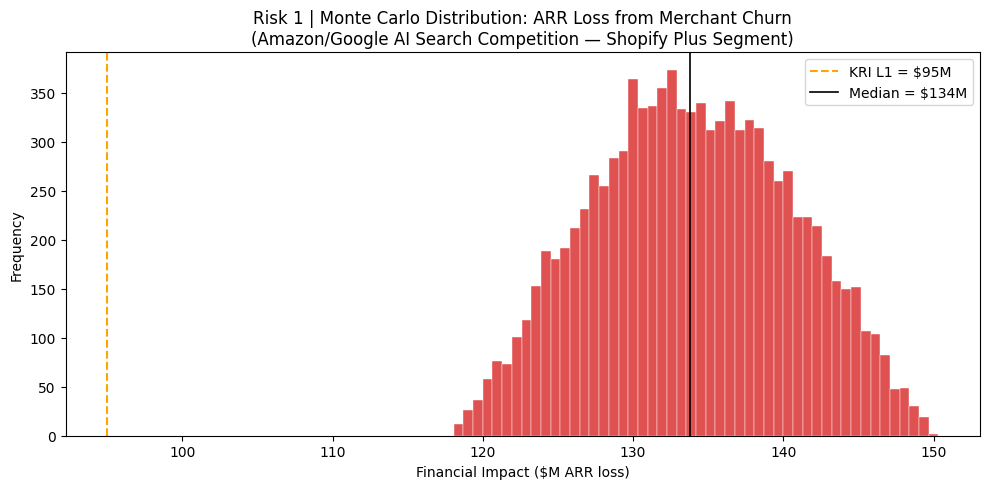

In [1]:
# ── RISK 1: Amazon/Google AI Search Competition ──────────────────────────────
# Indicator: Monthly Merchant Churn Rate (Shopify Plus segment)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
iterations = 10000

optimistic_r1  = 25
most_likely_r1 = 95
pessimistic_r1 = 380

def montecarlo_pert(optimistic, most_likely, pessimistic, iterations):
    results = []
    for _ in range(iterations):
        o  = np.random.uniform(optimistic  * 0.8, optimistic  * 1.2)
        ml = np.random.uniform(most_likely * 0.9, most_likely * 1.1)
        p  = np.random.uniform(pessimistic * 0.9, pessimistic * 1.2)
        pert_value = (o + 4 * ml + p) / 6
        results.append(pert_value)
    return np.array(results)

risk1_results = montecarlo_pert(optimistic_r1, most_likely_r1, pessimistic_r1, iterations)

p10 = np.percentile(risk1_results, 10)
p50 = np.percentile(risk1_results, 50)
p90 = np.percentile(risk1_results, 90)

print("=" * 55)
print("RISK 1 — Amazon/Google AI Search Competition")
print("=" * 55)
print(f"  Optimistic scenario (O):      ${optimistic_r1}M")
print(f"  Most likely scenario (ML):    ${most_likely_r1}M")
print(f"  Pessimistic scenario (P):     ${pessimistic_r1}M")
print("-" * 55)
print(f"  Monte Carlo P10 (best 10%):   ${p10:.1f}M ARR loss")
print(f"  Monte Carlo P50 (median):     ${p50:.1f}M ARR loss")
print(f"  Monte Carlo P90 (worst 10%):  ${p90:.1f}M ARR loss")
print("-" * 55)
pct_l1_r1 = (risk1_results > 95).mean() * 100
pct_l2_r1 = (risk1_results > 380).mean() * 100
print(f"  I&W L1 (>USD 95M):  {pct_l1_r1:.1f}% of simulations")
print(f"  I&W L2 (>USD 380M): {pct_l2_r1:.1f}% of simulations")
print("=" * 55)

# Note: KRI L2 line ($380M) excluded from chart — 0.0% of simulations exceeded
# this threshold, placing it entirely outside the simulated distribution range.
# L2 breach probability is reported in the printed output above.

t1 = 'Risk 1 | Monte Carlo Distribution: ARR Loss from Merchant Churn'
t2 = '(Amazon/Google AI Search Competition — Shopify Plus Segment)'

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(risk1_results, bins=50, color='#E05252', edgecolor='white', linewidth=0.3)
ax.axvline(95,  color='orange', linestyle='--', linewidth=1.5, label='KRI L1 = $95M')
ax.axvline(p50, color='black',  linestyle='-',  linewidth=1.2, label=f'Median = ${p50:.0f}M')
ax.set_title(t1 + '\n' + t2, fontsize=12)
ax.set_xlabel('Financial Impact ($M ARR loss)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


### 3.2. Risk 2: Regulatory Non-Compliance

**Indicator:** Number of High-Severity Regulatory Compliance Findings per Quarter

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Optimistic (O)** | 0 findings, full compliance maintained | USD 5M (remediation costs only) |
| **Most Likely (ML)** | 1 finding/quarter, moderate regulatory action | USD 85M fine |
| **Pessimistic (P)** | ≥2 findings or formal investigation initiated | USD 508M fine (GDPR 4% × ~USD 12.7B ARR) |

 RISK 2 — Regulatory Non-Compliance
  Optimistic scenario (O):      $5M
  Most likely scenario (ML):    $85M
  Pessimistic scenario (P):     $508M
------------------------------------------------------
  Monte Carlo P10 (best 10%):   $42.0M fine
  Monte Carlo P50 (median):     $128.2M fine
  Monte Carlo P90 (worst 10%):  $262.4M fine
------------------------------------------------------
  I&W L1 (>USD 85M):  70.4% of simulations
  I&W L2 (>USD 508M): 0.0% of simulations


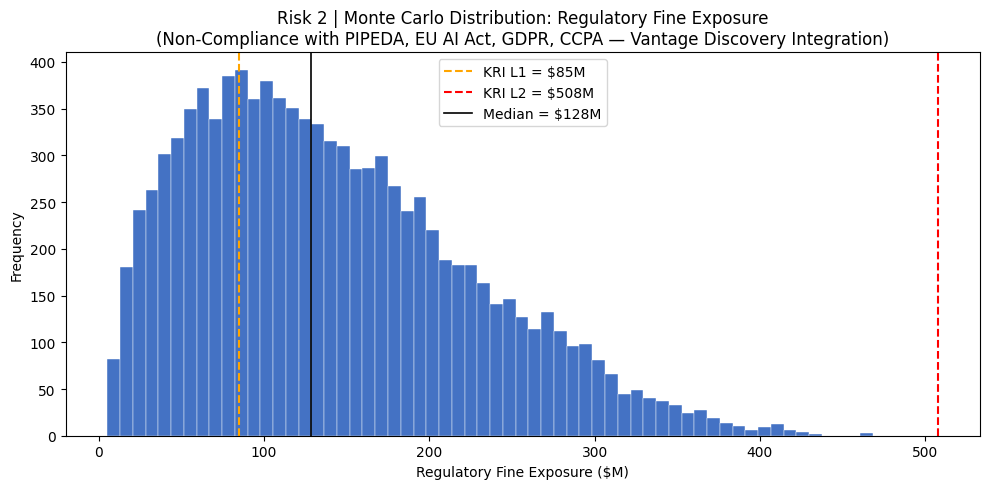

In [2]:
# ── RISK 2: Regulatory Non-Compliance ────────────────────────────────────
# Indicator: Number of High-Severity Regulatory Compliance Findings per Quarter

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)
N = 10_000

def pert_sample(low, mode, high, n, lam=4):
    a = 1 + lam * (mode - low) / (high - low)
    b = 1 + lam * (high - mode) / (high - low)
    return low + beta_dist.rvs(a, b, size=n) * (high - low)

optimistic_r2  = 5
most_likely_r2 = 85
pessimistic_r2 = 508

risk2_results = pert_sample(optimistic_r2, most_likely_r2, pessimistic_r2, N)

p10_r2  = np.percentile(risk2_results, 10)
p50_r2  = np.percentile(risk2_results, 50)
p90_r2  = np.percentile(risk2_results, 90)

kri_l1_r2 = 85
kri_l2_r2 = 508
pct_l1_r2 = (risk2_results > kri_l1_r2).mean() * 100
pct_l2_r2 = (risk2_results > kri_l2_r2).mean() * 100

print("=" * 54)
print(" RISK 2 — Regulatory Non-Compliance")
print("=" * 54)
print(f"  Optimistic scenario (O):      ${optimistic_r2}M")
print(f"  Most likely scenario (ML):    ${most_likely_r2}M")
print(f"  Pessimistic scenario (P):     ${pessimistic_r2}M")
print("-" * 54)
print(f"  Monte Carlo P10 (best 10%):   ${p10_r2:.1f}M fine")
print(f"  Monte Carlo P50 (median):     ${p50_r2:.1f}M fine")
print(f"  Monte Carlo P90 (worst 10%):  ${p90_r2:.1f}M fine")
print("-" * 54)
print(f"  I&W L1 (>USD 85M):  {pct_l1_r2:.1f}% of simulations")
print(f"  I&W L2 (>USD 508M): {pct_l2_r2:.1f}% of simulations")
print("=" * 54)

t1 = 'Risk 2 | Monte Carlo Distribution: Regulatory Fine Exposure'
t2 = '(Non-Compliance with PIPEDA, EU AI Act, GDPR, CCPA — Vantage Discovery Integration)'

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(risk2_results, bins=60, color='#4472C4', edgecolor='white', linewidth=0.3)
ax.axvline(kri_l1_r2, color='orange', linestyle='--', linewidth=1.5, label='KRI L1 = $85M')
ax.axvline(kri_l2_r2, color='red',    linestyle='--', linewidth=1.5, label='KRI L2 = $508M')
ax.axvline(p50_r2,    color='black',  linestyle='-',  linewidth=1.2, label=f'Median = ${p50_r2:.0f}M')
ax.set_title(t1 + '\n' + t2, fontsize=12)
ax.set_xlabel('Regulatory Fine Exposure ($M)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


### 3.3. Risk 3: New Merchant Segment Opportunity (Positive Risk)

**Indicator:** Net New Merchant Acquisition Rate from Competing Platforms (monthly % above historical baseline)

| Scenario | Condition | Financial Impact |
|---|---|---|
| **Pessimistic (P)** | Slow migration, competitor parity arrives early | USD 127M ARR upside |
| **Most Likely (ML)** | Moderate migration captured within 6–18 month window | USD 508M ARR upside |
| **Optimistic (O)** | Full window captured, accelerated migration | USD 762M ARR upside |

> Note: For positive risks, pessimistic = lowest upside and optimistic = highest upside.

 RISK 3 — New Merchant Segment Opportunity (Positive Risk)
  Pessimistic scenario (P):     $127M ARR upside
  Most likely scenario (ML):    $508M ARR upside
  Optimistic scenario (O):      $762M ARR upside
------------------------------------------------------
  Monte Carlo P10:  $325.2M ARR upside
  Monte Carlo P50:  $491.3M ARR upside
  Monte Carlo P90:  $639.0M ARR upside
------------------------------------------------------
  I&W L1 (>USD 508M): 45.1% of simulations
  I&W L2 (>USD 762M): 0.0% of simulations


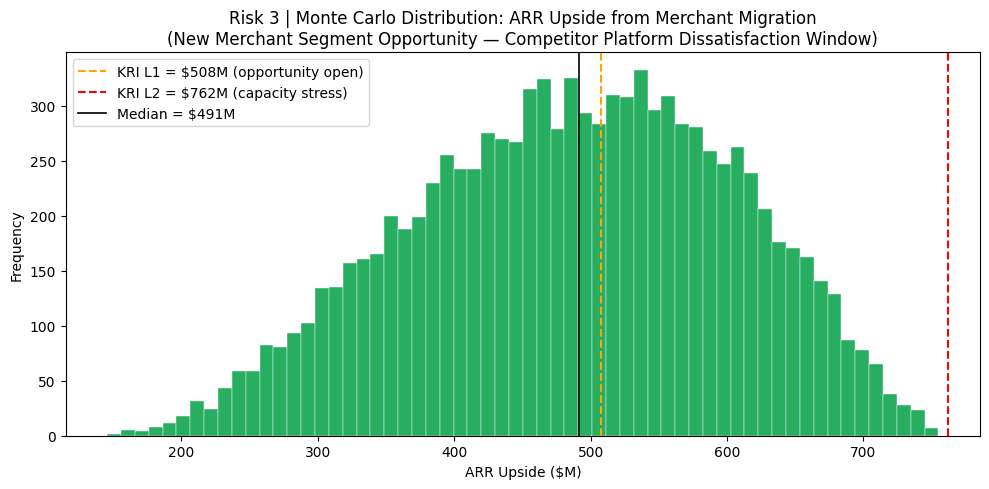

In [4]:
# ── RISK 3: New Merchant Segment Opportunity (Positive Risk) ──────────────
# Indicator: Net New Merchant Acquisition Rate from Competing Platforms

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)
N = 10_000

def pert_sample(low, mode, high, n, lam=4):
    a = 1 + lam * (mode - low) / (high - low)
    b = 1 + lam * (high - mode) / (high - low)
    return low + beta_dist.rvs(a, b, size=n) * (high - low)

# For positive risk: pessimistic = lowest upside, optimistic = highest upside
pessimistic_r3 = 127
most_likely_r3 = 508
optimistic_r3  = 762

risk3_results = pert_sample(pessimistic_r3, most_likely_r3, optimistic_r3, N)

p10_r3  = np.percentile(risk3_results, 10)
p50_r3  = np.percentile(risk3_results, 50)
p90_r3  = np.percentile(risk3_results, 90)

kri_l1_r3 = 508
kri_l2_r3 = 762
pct_l1_r3 = (risk3_results > kri_l1_r3).mean() * 100
pct_l2_r3 = (risk3_results > kri_l2_r3).mean() * 100

print("=" * 54)
print(" RISK 3 — New Merchant Segment Opportunity (Positive Risk)")
print("=" * 54)
print(f"  Pessimistic scenario (P):     ${pessimistic_r3}M ARR upside")
print(f"  Most likely scenario (ML):    ${most_likely_r3}M ARR upside")
print(f"  Optimistic scenario (O):      ${optimistic_r3}M ARR upside")
print("-" * 54)
print(f"  Monte Carlo P10:  ${p10_r3:.1f}M ARR upside")
print(f"  Monte Carlo P50:  ${p50_r3:.1f}M ARR upside")
print(f"  Monte Carlo P90:  ${p90_r3:.1f}M ARR upside")
print("-" * 54)
print(f"  I&W L1 (>USD 508M): {pct_l1_r3:.1f}% of simulations")
print(f"  I&W L2 (>USD 762M): {pct_l2_r3:.1f}% of simulations")
print("=" * 54)

t1 = 'Risk 3 | Monte Carlo Distribution: ARR Upside from Merchant Migration'
t2 = '(New Merchant Segment Opportunity — Competitor Platform Dissatisfaction Window)'

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(risk3_results, bins=60, color='#27AE60', edgecolor='white', linewidth=0.3)
ax.axvline(kri_l1_r3, color='orange', linestyle='--', linewidth=1.5, label='KRI L1 = $508M (opportunity open)')
ax.axvline(kri_l2_r3, color='red',    linestyle='--', linewidth=1.5, label='KRI L2 = $762M (capacity stress)')
ax.axvline(p50_r3,    color='black',  linestyle='-',  linewidth=1.2, label=f'Median = ${p50_r3:.0f}M')
ax.set_title(t1 + '\n' + t2, fontsize=12)
ax.set_xlabel('ARR Upside ($M)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Consolidated Risk Summary

The table below consolidates the Monte Carlo results across the three risk dimensions, enabling management to prioritize mitigation efforts based on financial exposure and KRI breach probability.

| Risk | P10 | P50 | P90 | L1 Breach | L2 Breach |
|---|---|---|---|---|---|
| Risk 1 — AI Competition (ARR loss) | USD 125.1M | USD 133.8M | USD 142.9M | 100.0% (>USD 95M) | 0.0% (>USD 380M) |
| Risk 2 — Regulatory Non-Compliance | USD 42.0M | USD 128.2M | USD 262.4M | 70.4% (>USD 85M) | 0.0% (>USD 508M) |
| Risk 3 — New Merchant Opportunity (upside) | USD 325.2M | USD 491.3M | USD 639.0M | 45.1% (>USD 508M) | 0.0% (>USD 762M) |

**Key findings:**

- **Risk 1 (Amazon/Google AI Competition)** represents the highest priority threat, with 100.0% probability of breaching the L1 warning threshold and a P50 of USD 133.8M in permanent ARR loss, confirming that merchant churn monitoring must remain the highest-frequency KRI review item.
- **Risk 2 (Regulatory Non-Compliance)** carries the most severe tail risk: a pessimistic-scenario GDPR fine of USD 508M (4% of Shopify's ~USD 12.7B ARR) represents the single largest potential financial consequence. With a 70.4% probability of breaching the L1 threshold and a P50 of USD 128.2M, moderate regulatory exposure is the most probable outcome. The L2 breach probability of 0.0% indicates the catastrophic scenario is extremely unlikely under current conditions, though it demands the most rigorous compliance controls of all three risks.
- **Risk 3 (New Merchant Opportunity)** is a time-sensitive positive risk with a P50 of USD 491.3M in incremental ARR upside and a 45.1% probability of exceeding the L1 threshold, available only within the 6–18 month window before competitors achieve AI search parity (BetaKit, 2025).

## 5. References

BetaKit. (2025, March 17). *Shopify acquires search startup Vantage Discovery.* https://betakit.com/shopify-acquires-vantage-discovery

Bold Commerce. (2025). *Understanding and calculating your eCommerce store's churn rate.* https://boldcommerce.com/blog/understanding-and-calculating-your-ecommerce-stores-churn-rate

DemandSage. (2026, April 13). *Shopify market share 2026 [global data].* https://demandsage.com/shopify-market-share/

Jarvie, E. (2026, February 18). *Shopify Q4 strength highlights AI and marketplace growth: analysts.* Proactive Investors. https://www.proactiveinvestors.com/companies/news/1087574

Lowe, T. (2023, January 3). *Monte Carlo simulations: Separating signal from noise in sampled success metrics.* Shopify Engineering Blog. https://shopify.engineering/monte-carlo-simulations-sampled-success-metrics

Recurly. (2024). *Subscription benchmarking report.* https://recurly.com/resources/benchmarks

RedStag Fulfillment. (2025). *Shopify market share stats 2026.* https://redstagfulfillment.com/shopify-market-share/

Shopify Inc. (2024–2026). *SEC Form 6-K and 8-K quarterly filings.* https://sec.gov — EDGAR search 'Shopify Inc.'